# 02_classical_ml_pipeline.ipynb

# P4 (Pipeline B) – Classical Machine Learning

This notebook implements **Pipeline B** of the project: classical ML models for BI-RADS classification, trained on the model-ready dataset produced by `01_data_preprocessing.ipynb`.

## Objectives

- Load the **preprocessed** train / validation / test splits (output of Phase 1/2)
- Feature extraction: `CountVectorizer` and `TF-IDF`
- Train and evaluate:
  - Multinomial Naive Bayes
  - Logistic Regression
  - Linear SVM
  - Random Forest
  - XGBoost *(optional — only runs if `xgboost` is installed)*
- Generate predictions on validation and test sets
- Save per-model metrics (Accuracy, Precision, Recall, Macro F1, Weighted F1, Runtime), confusion matrices, trained models, and a consolidated comparison table

> **Note:** This notebook does **not** re-run any text cleaning. It consumes `text`/`label` columns exactly as produced by `01_data_preprocessing.ipynb`.

> **Editing note:** As in the preprocessing notebook, every path here is derived from a single `BASE_DIR` variable in the **Configuration** cell. Set `BASE_DIR` to the *same* project folder you used in `01_data_preprocessing.ipynb` so this notebook can find the splits it produced, and everything else (model/prediction/metrics/figure output paths) is created automatically.

In [4]:
# ==========================================
# Imports
# ==========================================

import os
import json
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import joblib

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

# XGBoost is optional per the project spec — the notebook degrades gracefully if absent
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Configuration

**This is the only cell you should need to edit.** `BASE_DIR` must match the `BASE_DIR` used in `01_data_preprocessing.ipynb`, since this notebook reads that notebook's output splits. Every input and output path below is derived from `BASE_DIR` (plus the small set of `*_COLUMN` / `MODEL_CONFIGS` settings you may want to tweak).

In [5]:
from google.colab import drive
drive.mount('/content/mydrive')

Mounted at /content/mydrive


In [6]:
# ============================================================
# GLOBAL CONFIGURATION — EDIT ONLY THIS CELL
# ============================================================

# --- 1) The ONE variable that controls where everything is read from / written to ---
#     Must match BASE_DIR from 01_data_preprocessing.ipynb.
BASE_DIR = '/content/mydrive/MyDrive/NLP_Research_Project'

# --- 2) Column names in the processed dataset ---
ID_COLUMN = 'id'
TEXT_COLUMN = 'text'
LABEL_COLUMN = 'label'

# --- 3) Which feature extractors / models to run ---
FEATURE_TYPES = ['countvectorizer', 'tfidf']
MAX_FEATURES = 20000     # vocabulary cap for both vectorizers
NGRAM_RANGE = (1, 2)     # unigrams + bigrams

# ============================================================
# Everything below this line is DERIVED from BASE_DIR.
# You should not need to edit it.
# ============================================================

# --- Inputs: splits produced by 01_data_preprocessing.ipynb ---
SPLITS_DIR = os.path.join(BASE_DIR, 'data', 'splits')
TRAIN_PATH = os.path.join(SPLITS_DIR, 'train.csv')
VAL_PATH = os.path.join(SPLITS_DIR, 'validation.csv')
TEST_PATH = os.path.join(SPLITS_DIR, 'test.csv')

# --- Outputs ---
DIRS = {
    'vectorizers': os.path.join(BASE_DIR, 'results', 'models', 'classical_ml', 'vectorizers'),
    'models':      os.path.join(BASE_DIR, 'results', 'models', 'classical_ml', 'trained_models'),
    'predictions': os.path.join(BASE_DIR, 'results', 'predictions'),
    'metrics':     os.path.join(BASE_DIR, 'results', 'metrics'),
    'confusion':   os.path.join(BASE_DIR, 'results', 'confusion_matrices', 'classical_ml'),
    'figures':     os.path.join(BASE_DIR, 'results', 'figures', 'classical_ml'),
}

for _d in DIRS.values():
    os.makedirs(_d, exist_ok=True)

PATHS = {
    'ml_predictions_val':   os.path.join(DIRS['predictions'], 'ml_predictions_validation.csv'),
    'ml_predictions_test':  os.path.join(DIRS['predictions'], 'ml_predictions_test.csv'),
    'metrics_summary':      os.path.join(DIRS['metrics'], 'metrics_summary_classical_ml.csv'),
    'comparison_tables':    os.path.join(DIRS['metrics'], 'comparison_tables.xlsx'),
}

print('BASE_DIR  :', BASE_DIR)
print('TRAIN_PATH:', TRAIN_PATH)
print('VAL_PATH  :', VAL_PATH)
print('TEST_PATH :', TEST_PATH)
for k, v in DIRS.items():
    print(f"  [{k}] -> {v}")
print()
print('XGBoost available:', HAS_XGBOOST)

BASE_DIR  : /content/mydrive/MyDrive/NLP_Research_Project
TRAIN_PATH: /content/mydrive/MyDrive/NLP_Research_Project/data/splits/train.csv
VAL_PATH  : /content/mydrive/MyDrive/NLP_Research_Project/data/splits/validation.csv
TEST_PATH : /content/mydrive/MyDrive/NLP_Research_Project/data/splits/test.csv
  [vectorizers] -> /content/mydrive/MyDrive/NLP_Research_Project/results/models/classical_ml/vectorizers
  [models] -> /content/mydrive/MyDrive/NLP_Research_Project/results/models/classical_ml/trained_models
  [predictions] -> /content/mydrive/MyDrive/NLP_Research_Project/results/predictions
  [metrics] -> /content/mydrive/MyDrive/NLP_Research_Project/results/metrics
  [confusion] -> /content/mydrive/MyDrive/NLP_Research_Project/results/confusion_matrices/classical_ml
  [figures] -> /content/mydrive/MyDrive/NLP_Research_Project/results/figures/classical_ml

XGBoost available: True


## 2. Load Preprocessed Data

Loads the `train.csv` / `validation.csv` / `test.csv` files written by `01_data_preprocessing.ipynb` (columns: `id`, `raw_text`, `text`, `label`).

In [7]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

# Guard against any stray NaNs in the text column (e.g. if a report became empty
# after preprocessing) so vectorizers don't choke on them
for _df in (train_df, val_df, test_df):
    _df[TEXT_COLUMN] = _df[TEXT_COLUMN].fillna('')

print('Train:', train_df.shape, ' Validation:', val_df.shape, ' Test:', test_df.shape)
print('Classes:', sorted(train_df[LABEL_COLUMN].unique()))
train_df.head()

Train: (6425, 4)  Validation: (1377, 4)  Test: (1377, 4)
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


,id,raw_text,text,label
0,Acc13491,Clinical indication:\n\n tracking.\n\nFamily h...,clinical indication tracking. family history o...,2
1,Acc6472,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings partial...,2
2,Acc13195,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings predomi...,2
3,Acc2281,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings ventric...,2
4,Acc18618,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings heterog...,2


## 3. Feature Extraction

Fits `CountVectorizer` and `TF-IDF` **on the training set only**, then transforms validation/test with the fitted vocabulary (never fit on val/test — that would leak information).

In [8]:
def build_vectorizer(kind):
    if kind == 'countvectorizer':
        return CountVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)
    elif kind == 'tfidf':
        return TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)
    else:
        raise ValueError(f"Unknown feature type: {kind}")


features = {}  # feature_type -> dict(vectorizer, X_train, X_val, X_test)

for feature_type in FEATURE_TYPES:
    vectorizer = build_vectorizer(feature_type)
    X_train = vectorizer.fit_transform(train_df[TEXT_COLUMN])
    X_val = vectorizer.transform(val_df[TEXT_COLUMN])
    X_test = vectorizer.transform(test_df[TEXT_COLUMN])

    joblib.dump(vectorizer, os.path.join(DIRS['vectorizers'], f'{feature_type}_vectorizer.pkl'))

    features[feature_type] = {
        'vectorizer': vectorizer,
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
    }
    print(f"[{feature_type}] vocabulary size: {len(vectorizer.vocabulary_)} | "
          f"X_train shape: {X_train.shape}")

[countvectorizer] vocabulary size: 15494 | X_train shape: (6425, 15494)
[tfidf] vocabulary size: 15494 | X_train shape: (6425, 15494)


## 4. Model Definitions

Edit `MODEL_CONFIGS` to add, remove, or re-tune models — everything downstream (training, evaluation, saving) loops over this dict automatically.

In [9]:
def get_model_configs():
    configs = {
        'naive_bayes': MultinomialNB(),
        'logistic_regression': LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
        ),
        'linear_svm': LinearSVC(
            class_weight='balanced', random_state=RANDOM_STATE
        ),
        'random_forest': RandomForestClassifier(
            n_estimators=300, class_weight='balanced',
            n_jobs=-1, random_state=RANDOM_STATE
        ),
    }
    if HAS_XGBOOST:
        configs['xgboost'] = XGBClassifier(
            n_estimators=300, eval_metric='mlogloss',
            n_jobs=-1, random_state=RANDOM_STATE
        )
    return configs

MODEL_CONFIGS = get_model_configs()
print('Models to train:', list(MODEL_CONFIGS.keys()))

Models to train: ['naive_bayes', 'logistic_regression', 'linear_svm', 'random_forest', 'xgboost']


## 5. Train, Evaluate & Save

For every (feature type × model) combination:
1. Train on `X_train`
2. Predict on validation (and test) sets
3. Compute Accuracy / Precision / Recall / Macro F1 / Weighted F1 / runtime
4. Save predictions, a confusion matrix figure, and the trained model

In [10]:
def evaluate_predictions(y_true, y_pred, labels):
    acc = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'accuracy': acc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
    }


def save_confusion_matrix(y_true, y_pred, labels, title, out_path):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close(fig)

In [11]:
all_labels = sorted(train_df[LABEL_COLUMN].unique())

metrics_rows = []
val_prediction_frames = []
test_prediction_frames = []

for feature_type, feat in features.items():
    X_train, X_val, X_test = feat['X_train'], feat['X_val'], feat['X_test']
    y_train, y_val, y_test = train_df[LABEL_COLUMN], val_df[LABEL_COLUMN], test_df[LABEL_COLUMN]

    for model_name, model in MODEL_CONFIGS.items():
        run_id = f"{feature_type}__{model_name}"
        print(f"Training {run_id} ...")

        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        t0 = time.time()
        val_pred = model.predict(X_val)
        val_predict_time = time.time() - t0

        t0 = time.time()
        test_pred = model.predict(X_test)
        test_predict_time = time.time() - t0

        val_metrics = evaluate_predictions(y_val, val_pred, all_labels)
        test_metrics = evaluate_predictions(y_test, test_pred, all_labels)

        row = {
            'feature_type': feature_type,
            'model': model_name,
            'train_time_sec': train_time,
            'val_predict_time_sec': val_predict_time,
            'test_predict_time_sec': test_predict_time,
        }
        row.update({f'val_{k}': v for k, v in val_metrics.items()})
        row.update({f'test_{k}': v for k, v in test_metrics.items()})
        metrics_rows.append(row)

        # --- predictions ---
        val_prediction_frames.append(pd.DataFrame({
            ID_COLUMN: val_df[ID_COLUMN],
            'true_label': y_val.values,
            'predicted_label': val_pred,
            'feature_type': feature_type,
            'model': model_name,
        }))
        test_prediction_frames.append(pd.DataFrame({
            ID_COLUMN: test_df[ID_COLUMN],
            'true_label': y_test.values,
            'predicted_label': test_pred,
            'feature_type': feature_type,
            'model': model_name,
        }))

        # --- confusion matrix (validation set) ---
        cm_path = os.path.join(DIRS['confusion'], f'{run_id}_val_confusion_matrix.png')
        save_confusion_matrix(y_val, val_pred, all_labels, f'{run_id} (validation)', cm_path)

        # --- trained model ---
        joblib.dump(model, os.path.join(DIRS['models'], f'{run_id}.pkl'))

        val_acc = val_metrics['accuracy']
        val_f1m = val_metrics['f1_macro']
        print(f"  val_accuracy={val_acc:.4f}  val_f1_macro={val_f1m:.4f}  train_time={train_time:.2f}s")

print("\nAll models trained.")

Training countvectorizer__naive_bayes ...
  val_accuracy=0.7967  val_f1_macro=0.3177  train_time=0.01s
Training countvectorizer__logistic_regression ...
  val_accuracy=0.9005  val_f1_macro=0.6960  train_time=16.31s
Training countvectorizer__linear_svm ...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  val_accuracy=0.9005  val_f1_macro=0.6806  train_time=2.20s
Training countvectorizer__random_forest ...
  val_accuracy=0.8584  val_f1_macro=0.4222  train_time=33.13s
Training countvectorizer__xgboost ...
  val_accuracy=0.9129  val_f1_macro=0.7316  train_time=34.87s
Training tfidf__naive_bayes ...
  val_accuracy=0.7967  val_f1_macro=0.1318  train_time=0.01s
Training tfidf__logistic_regression ...
  val_accuracy=0.8286  val_f1_macro=0.6112  train_time=4.37s
Training tfidf__linear_svm ...
  val_accuracy=0.9078  val_f1_macro=0.7375  train_time=0.59s
Training tfidf__random_forest ...
  val_accuracy=0.8344  val_f1_macro=0.3117  train_time=27.01s
Training tfidf__xgboost ...
  val_accuracy=0.9005  val_f1_macro=0.6502  train_time=128.77s

All models trained.


## 6. Save Predictions & Metrics

In [12]:
val_predictions = pd.concat(val_prediction_frames, ignore_index=True)
test_predictions = pd.concat(test_prediction_frames, ignore_index=True)

val_predictions.to_csv(PATHS['ml_predictions_val'], index=False)
test_predictions.to_csv(PATHS['ml_predictions_test'], index=False)

metrics_summary = pd.DataFrame(metrics_rows).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
metrics_summary.to_csv(PATHS['metrics_summary'], index=False)

print(f"Saved validation predictions -> {PATHS['ml_predictions_val']}")
print(f"Saved test predictions       -> {PATHS['ml_predictions_test']}")
print(f"Saved metrics summary        -> {PATHS['metrics_summary']}")

metrics_summary[['feature_type', 'model', 'val_accuracy', 'val_f1_macro', 'val_f1_weighted', 'train_time_sec']]

Saved validation predictions -> /content/mydrive/MyDrive/NLP_Research_Project/results/predictions/ml_predictions_validation.csv
Saved test predictions       -> /content/mydrive/MyDrive/NLP_Research_Project/results/predictions/ml_predictions_test.csv
Saved metrics summary        -> /content/mydrive/MyDrive/NLP_Research_Project/results/metrics/metrics_summary_classical_ml.csv


,feature_type,model,val_accuracy,val_f1_macro,val_f1_weighted,train_time_sec
0,tfidf,linear_svm,0.907771,0.737544,0.909121,0.593904
1,countvectorizer,xgboost,0.912854,0.731613,0.908686,34.870842
2,countvectorizer,logistic_regression,0.900508,0.696023,0.903366,16.305059
3,countvectorizer,linear_svm,0.900508,0.680642,0.899452,2.201394
4,tfidf,xgboost,0.900508,0.650216,0.894283,128.765147
5,tfidf,logistic_regression,0.828613,0.611224,0.848936,4.369495
6,countvectorizer,random_forest,0.858388,0.422164,0.824970,33.130615
7,countvectorizer,naive_bayes,0.796659,0.317684,0.791472,0.011852
8,tfidf,random_forest,0.834423,0.311664,0.785985,27.014101
9,tfidf,naive_bayes,0.796659,0.131816,0.710055,0.010865


In [13]:
# --- Comparison workbook (one sheet per feature type, plus an overall sheet) ---
try:
    with pd.ExcelWriter(PATHS['comparison_tables'], engine='openpyxl') as writer:
        metrics_summary.to_excel(writer, sheet_name='all_models', index=False)
        for feature_type in FEATURE_TYPES:
            subset = metrics_summary[metrics_summary['feature_type'] == feature_type]
            subset.to_excel(writer, sheet_name=feature_type[:31], index=False)
    print(f"Saved comparison workbook -> {PATHS['comparison_tables']}")
except ImportError:
    fallback = PATHS['comparison_tables'].replace('.xlsx', '.csv')
    metrics_summary.to_csv(fallback, index=False)
    print(f"openpyxl not available — saved comparison table as CSV instead -> {fallback}")

Saved comparison workbook -> /content/mydrive/MyDrive/NLP_Research_Project/results/metrics/comparison_tables.xlsx


## 7. Model Comparison Plot

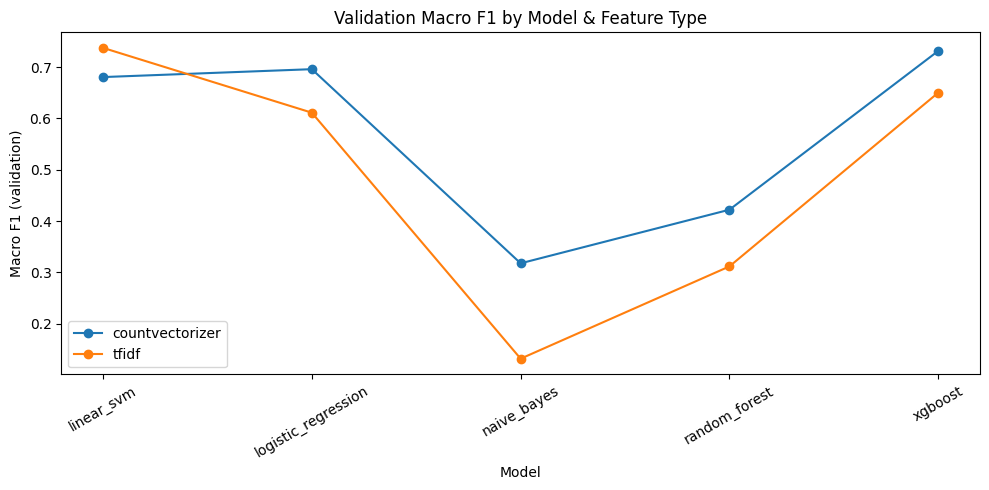

In [14]:
plt.figure(figsize=(10, 5))
for feature_type in FEATURE_TYPES:
    subset = metrics_summary[metrics_summary['feature_type'] == feature_type].sort_values('model')
    plt.plot(subset['model'], subset['val_f1_macro'], marker='o', label=feature_type)

plt.title('Validation Macro F1 by Model & Feature Type')
plt.xlabel('Model')
plt.ylabel('Macro F1 (validation)')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'model_comparison_macro_f1.png'))
plt.show()

## 8. Best Model — Detailed Report

In [15]:
best_row = metrics_summary.iloc[0]
best_feature_type, best_model_name = best_row['feature_type'], best_row['model']
best_f1_macro = best_row['val_f1_macro']
print(f"Best model on validation: {best_model_name} ({best_feature_type}) | val_f1_macro={best_f1_macro:.4f}")

best_val_pred = val_predictions[
    (val_predictions['feature_type'] == best_feature_type) &
    (val_predictions['model'] == best_model_name)
]

print("\nClassification report (validation):")
print(classification_report(best_val_pred['true_label'], best_val_pred['predicted_label'], zero_division=0))

best_test_pred = test_predictions[
    (test_predictions['feature_type'] == best_feature_type) &
    (test_predictions['model'] == best_model_name)
]
print("Classification report (test):")
print(classification_report(best_test_pred['true_label'], best_test_pred['predicted_label'], zero_division=0))

Best model on validation: linear_svm (tfidf) | val_f1_macro=0.7375

Classification report (validation):
              precision    recall  f1-score   support

           0       0.78      0.77      0.77        91
           1       0.90      0.95      0.92        38
           2       0.96      0.95      0.96      1098
           3       0.57      0.65      0.61       107
           4       0.73      0.69      0.71        32
           5       0.50      0.25      0.33         4
           6       0.86      0.86      0.86         7

    accuracy                           0.91      1377
   macro avg       0.76      0.73      0.74      1377
weighted avg       0.91      0.91      0.91      1377

Classification report (test):
              precision    recall  f1-score   support

           0       0.72      0.84      0.77        91
           1       0.89      0.84      0.86        38
           2       0.97      0.95      0.96      1099
           3       0.52      0.59      0.55       10

## 9. Final Checklist

In [16]:
print('Preprocessed Train/Validation/Test Data Loaded')
print('CountVectorizer & TF-IDF Features Extracted (fit on train only)')
print('Models Trained: Naive Bayes, Logistic Regression, Linear SVM, Random Forest' + (', XGBoost' if HAS_XGBOOST else ' (XGBoost skipped — not installed)'))
print('Validation & Test Predictions Saved')
print('Per-Model Metrics (Accuracy, Precision, Recall, Macro F1, Weighted F1, Runtime) Saved')
print('Confusion Matrices Saved')
print('Trained Models & Vectorizers Saved (for SHAP/LIME & reuse)')
print('Comparison Table Saved:', PATHS['comparison_tables'])

Preprocessed Train/Validation/Test Data Loaded
CountVectorizer & TF-IDF Features Extracted (fit on train only)
Models Trained: Naive Bayes, Logistic Regression, Linear SVM, Random Forest, XGBoost
Validation & Test Predictions Saved
Per-Model Metrics (Accuracy, Precision, Recall, Macro F1, Weighted F1, Runtime) Saved
Confusion Matrices Saved
Trained Models & Vectorizers Saved (for SHAP/LIME & reuse)
Comparison Table Saved: /content/mydrive/MyDrive/NLP_Research_Project/results/metrics/comparison_tables.xlsx
